In [5]:
import json
import os
from pathlib import Path
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Add the repo folder for imports
dirpath_repo_root = Path().resolve().parent
dirpath_self = Path().resolve()
sys.path.append(str(dirpath_repo_root))
sys.path.append(str(dirpath_self))
print(f'Repo root: {dirpath_repo_root}')
print(f'Working folder: {dirpath_self}')

from analysis.ou_tuning import batch_utils

Repo root: /ddn/niknovikov19/repo/A1_OUinp
Working folder: /ddn/niknovikov19/repo/A1_OUinp/batch_processing


In [6]:
def _get_fpath_by_templ(dirpath: Path, fname_templ: str) -> str:
    files = list(dirpath.glob(fname_templ))
    if len(files) != 1:
        print(f'Path for search: {str(dirpath)}')
        print(f'Name template: {fname_templ}')
        raise RuntimeError('Should be exactly one filename match')
    return files[0]

In [7]:
dirpath_exp = dirpath_self / 'exp_result_example'

dirpath_res = dirpath_exp / 'results'
dirpath_cfg = dirpath_exp / 'cfg'

fname_data_templ = 'result_{job:05d}_*.json'
fname_cfg_templ = 'cfg_*.json'

# Populations to read from the result jsons
pops_used = ['SOM2', 'SOM3', 'SOM5B']

# Extract (param_grid -> job_id) xarray from cfg folder
job_idx_xr = batch_utils.extract_batch_params_to_xr(
    dirpath_cfg,
    cfg_param_fields={
        'drxe_pos': 'drxe_pos',   # xarray : json
        'rxi_pos': 'rxi_pos'
    },
    fname_cfg_templ=fname_cfg_templ,
    job_pos_in_fname=1
)
job_idx_xr

<xarray.DataArray 'job_id' (drxe_pos: 7, rxi_pos: 7)> Size: 392B
array([[nan, nan, 14., 21., 28., 35., 42.],
       [nan, nan, 15., 22., 29., 36., 43.],
       [nan,  9., 16., 23., 30., 37., 44.],
       [nan, 10., 17., 24., 31., 38., 45.],
       [nan, 11., 18., 25., 32., 39., 46.],
       [ 5., 12., 19., 26., 33., 40., 47.],
       [ 6., 13., 20., 27., 34., 41., 48.]])
Coordinates:
  * drxe_pos  (drxe_pos) float64 56B 0.0 0.1667 0.3333 0.5 0.6667 0.8333 1.0
  * rxi_pos   (rxi_pos) float64 56B 0.0 0.1667 0.3333 0.5 0.6667 0.8333 1.0

In [8]:
# Variable names (in xarray : in result json file)
vars = {
    'rate': 'rates', 'cv': 'cvs',
    'vmin': 'v_med_min', 'vmax': 'v_med_max',
    'vavg': 'v_med_avg'
}

# Dimensions: batch grid + pop
dims_new = list(job_idx_xr.dims) + ['pop']
coords_new = dict(job_idx_xr.coords) | {'pop': pops_used}
sz_new = [job_idx_xr.sizes[d] for d in job_idx_xr.dims] + [len(pops_used)]

# Empty xarray
X = {}
Z = xr.DataArray(np.full(sz_new, np.nan),
                 dims=dims_new, coords=coords_new)
for v in vars:
    X[v] = Z.copy()
X = xr.Dataset(X)

# Iterate over all cells in job_idx_xr (i.e. over job results)
for idx in np.ndindex(job_idx_xr.shape):
    # Output slice for this job
    job_id = job_idx_xr.values[idx]
    if np.isnan(job_id):
        continue
    sel = {dim: idx[i] for i, dim in enumerate(job_idx_xr.dims)}
    
    # Generate file path of the job result
    fname_data = fname_data_templ.format(job=int(job_id))
    fpath_data = _get_fpath_by_templ(dirpath_res, fname_data)
    #print(job_id, fpath_data.name)

    # Load job result from json and assign it to a slice in X
    with open(fpath_data, 'r') as fid:
        res = json.load(fid)
    for v, v_res in vars.items():
        for pop in pops_used:
            X[v][sel].loc[{'pop': pop}] = res[v_res][pop]
X

<xarray.Dataset> Size: 6kB
Dimensions:   (drxe_pos: 7, rxi_pos: 7, pop: 3)
Coordinates:
  * drxe_pos  (drxe_pos) float64 56B 0.0 0.1667 0.3333 0.5 0.6667 0.8333 1.0
  * rxi_pos   (rxi_pos) float64 56B 0.0 0.1667 0.3333 0.5 0.6667 0.8333 1.0
  * pop       (pop) <U5 60B 'SOM2' 'SOM3' 'SOM5B'
Data variables:
    rate      (drxe_pos, rxi_pos, pop) float64 1kB nan nan nan ... 2.586 1.071
    cv        (drxe_pos, rxi_pos, pop) float64 1kB nan nan nan ... 1.473 0.7567
    vmin      (drxe_pos, rxi_pos, pop) float64 1kB nan nan nan ... -43.24 -41.67
    vmax      (drxe_pos, rxi_pos, pop) float64 1kB nan nan nan ... -38.36 -38.37
    vavg      (drxe_pos, rxi_pos, pop) float64 1kB nan nan nan ... -40.71 -39.94

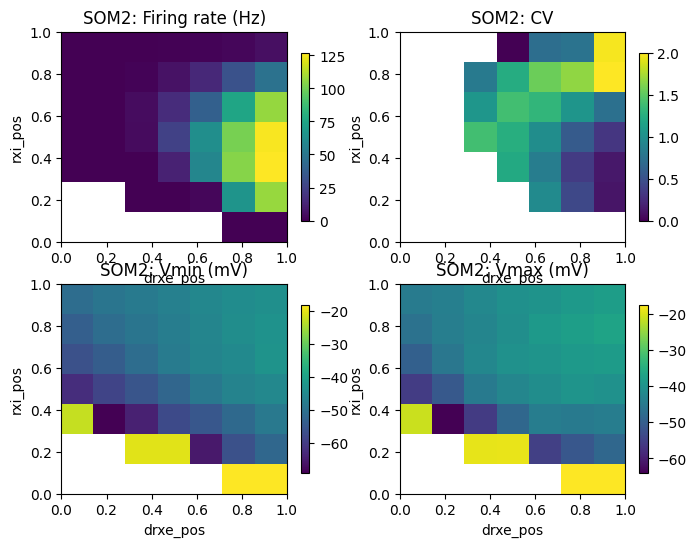

In [9]:
# Population to visualize
pop = 'SOM2'

# Extract data variables for visualization
r = X['rate'].sel(pop=pop)
cv = X['cv'].sel(pop=pop)
vmin = X['vmin'].sel(pop=pop)
vmax = X['vmax'].sel(pop=pop)

plots = [
    ("Firing rate (Hz)", r),
    ("CV", cv),
    ("Vmin (mV)", vmin),
    ("Vmax (mV)", vmax),
]

# Coordinate names
coord_x, coord_y = 'drxe_pos', 'rxi_pos'

# 2-D region to visualize
x0, x1 = float(r[coord_x].min()), float(r[coord_x].max())
y0, y1 = float(r[coord_y].min()), float(r[coord_y].max())

# Plot 2-D colormaps
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
for ax, (title, da) in zip(axs.ravel(), plots):
    im = ax.imshow(da.T, extent=(x0, x1, y0, y1),
                   aspect='auto', origin='lower',
                   interpolation='nearest')
    ax.set_title(f'{pop}: {title}')
    ax.set_xlabel(coord_x)
    ax.set_ylabel(coord_y)
    fig.colorbar(im, ax=ax, shrink=0.8)